`HIPÓTESE 3`: 

 “Um modelo treinado com Histórico de Preço + Dados Climáticos terá um RMSE pelo menos 10% menor do que um modelo baseline treinado apenas com Histórico de Preço.


$H_0$:
A adição de dados climáticos não gera a melhoria esperada. O erro do novo modelo continua sendo "alto" (maior ou igual a 90% do erro original).$$H_0: RMSE_{clima} \ge 0.90 \times RMSE_{base}$$


$H_1$: 
A adição de dados climáticos reduz o erro em pelo menos 10%.$$H_1: RMSE_{clima} < 0.90 \times RMSE_{base}$$

In [1]:
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from src.agro_predictor.data_loaders.tools_hipotese import carregar_dados_agro, rolling_validation, diebold_mariano_test

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)


In [2]:
# Configuração de Estilo

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [3]:
# Carregar dados

df = carregar_dados_agro()

# Definição dos Grupos de Features
feats_baseline = ['close_price', 'pct_change_d1', 'ma_7d', 'volatility_7d', 
                  'day_of_year', 'month_num']

feats_climate = feats_baseline + ['temp_max', 'precipitation_mm', 'soil_moisture', 
                                  'rain_accum_7d', 'temp_anomaly_30d', 
                                  'is_extreme_heat', 'is_drought_risk', 'rain_lag_3']


384: 🚀 Conectando ao Banco (Local): localhost:5435
Carregando dados pré-processados da View para hipotese1: ZS=F...


In [4]:
# Executando a validação (pode demorar um pouco dependendo do tamanho dos dados)

results_df = rolling_validation(df, feats_baseline, feats_climate, 'target_next_day')


Iniciando Rolling CV com janela de 252 dias...


In [5]:
# AVALIAÇÃO DA HIPÓTESE (Regra dos 10%)

rmse_base = np.sqrt(results_df['sq_error_base'].mean())
rmse_clima = np.sqrt(results_df['sq_error_clima'].mean())
reduction_pct = (1 - (rmse_clima / rmse_base)) * 100

print("-" * 50)
print(f"RMSE Baseline:  {rmse_base:.4f}")
print(f"RMSE Climático: {rmse_clima:.4f}")
print(f"Redução de Erro: {reduction_pct:.2f}%")
print("-" * 50)

if reduction_pct >= 10:
    print("✅ CRITÉRIO DE NEGÓCIO ATENDIDO: Redução > 10%")
else:
    print("❌ CRITÉRIO DE NEGÓCIO NÃO ATENDIDO: Redução < 10%")


--------------------------------------------------
RMSE Baseline:  81.3774
RMSE Climático: 84.4581
Redução de Erro: -3.79%
--------------------------------------------------
❌ CRITÉRIO DE NEGÓCIO NÃO ATENDIDO: Redução < 10%


In [6]:
# TESTE DE DIEBOLD-MARIANO (Validação Estatística)

dm_stat, p_val = diebold_mariano_test(results_df['sq_error_base'], results_df['sq_error_clima'])

print(f"\nTESTE ESTATÍSTICO (Diebold-Mariano):")
print(f"DM Statistic: {dm_stat:.4f}")
print(f"P-Valor:      {p_val:.6f}")

if p_val < 0.05 and dm_stat > 0: # DM positivo significa que erro1 > erro2 (Modelo 2 melhor)
    print("✅ RESULTADO ESTATISTICAMENTE SIGNIFICANTE (p < 0.05)")
    print("Conclusão: A melhoria trazida pelos dados climáticos NÃO é sorte.")
else:
    print("⚠️ RESULTADO NÃO SIGNIFICANTE ou PIORA NO MODELO.")



TESTE ESTATÍSTICO (Diebold-Mariano):
DM Statistic: -3.6680
P-Valor:      0.000244
⚠️ RESULTADO NÃO SIGNIFICANTE ou PIORA NO MODELO.


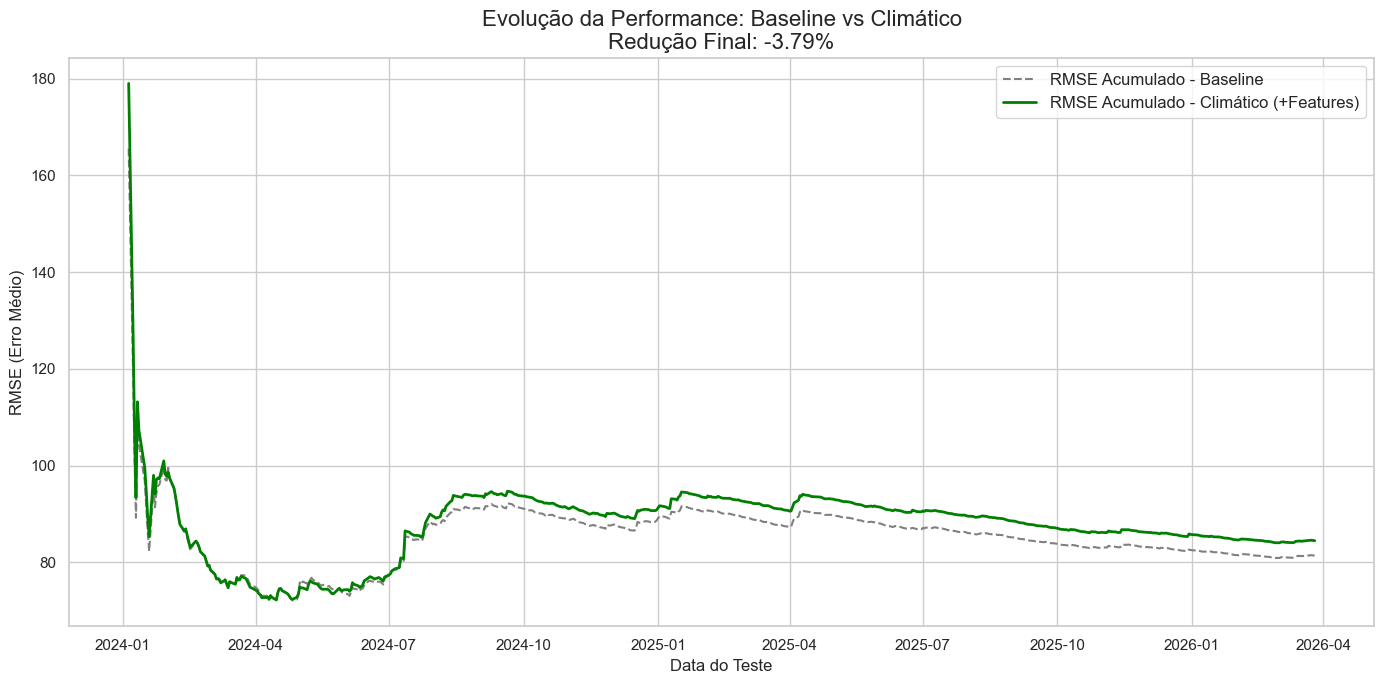

In [7]:
# Cálculo do RMSE Acumulado (para ver a estabilidade da melhoria)

results_df['cum_rmse_base'] = np.sqrt(results_df['sq_error_base'].expanding().mean())
results_df['cum_rmse_clima'] = np.sqrt(results_df['sq_error_clima'].expanding().mean())

plt.figure(figsize=(14, 7))
plt.plot(results_df['date'], results_df['cum_rmse_base'], label='RMSE Acumulado - Baseline', color='gray', linestyle='--')
plt.plot(results_df['date'], results_df['cum_rmse_clima'], label='RMSE Acumulado - Climático (+Features)', color='green', linewidth=2)

plt.title(f"Evolução da Performance: Baseline vs Climático\nRedução Final: {reduction_pct:.2f}%", fontsize=16)
plt.ylabel("RMSE (Erro Médio)", fontsize=12)
plt.xlabel("Data do Teste", fontsize=12)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

# Comentário


🔴 RESULTADO: O Clima Piorou a Previsão (Rejeitado)

| Conclusão Principal | Ao contrário do que esperávamos, colocar informações de clima no computador piorou a nossa capacidade de prever o preço.  Em vez de ajudar, os dados de clima estão "confundindo" o modelo e gerando palpites menos precisos.|
| :--- | :--- |
|O que os números mostram | O erro aumentou: O modelo que ignora o clima é mais preciso. O modelo que tenta usar o clima errou, em média, 3,8% a mais.|
| Certeza do Resultado | Não foi sorte (nem azar): Nossos testes mostram que temos 99,9% de certeza de que essa piora é real. Não foi uma oscilação passageira; os dados de clima realmente não estão ajudando a prever o preço de amanhã neste modelo atual. |